<a href="https://colab.research.google.com/github/Rogelio756/Equipo8-Grupo8-SIC-2025-/blob/YOLOv8n_train/YOLOv8_dataset_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importar archivos JSON


In [ ]:
import json
import pandas as pd
import os

zipped_json_path = '/content/drive/MyDrive/AI_PROJECT/bdd100k_labels_images_train.json.zip'
unzip_dir = '/content/json_data'
os.makedirs(unzip_dir, exist_ok=True)
!unzip -q -o "{zipped_json_path}" -d "{unzip_dir}"
unzipped_json_filename = os.path.basename(zipped_json_path).replace('.zip', '')
json_path = os.path.join(unzip_dir, unzipped_json_filename)

try:
    with open(json_path, 'r') as f:
        bdd_labels = json.load(f)
    print(f"Archivo JSON cargado exitosamente. Se encontraron {len(bdd_labels)} entradas.")
    print("\nPrimeras 5 entradas del archivo JSON:")
    for i, entry in enumerate(bdd_labels[:5]):
        print(f"Entrada {i+1}: {entry}")

except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {json_path}")
except json.JSONDecodeError:
    print(f"Error: No se pudo decodificar el archivo JSON. Asegúrate de que sea un JSON válido.")
except Exception as e:
    print(f"Ocurrió un error inesperado al cargar el archivo JSON: {e}")

Archivo JSON cargado exitosamente. Se encontraron 69863 entradas.

Primeras 5 entradas del archivo JSON:
Entrada 1: {'name': '0000f77c-6257be58.jpg', 'attributes': {'weather': 'clear', 'scene': 'city street', 'timeofday': 'daytime'}, 'timestamp': 10000, 'labels': [{'category': 'traffic light', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1125.902264, 'y1': 133.184488, 'x2': 1156.978645, 'y2': 210.875445}, 'id': 0}, {'category': 'traffic light', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1156.978645, 'y1': 136.637417, 'x2': 1191.50796, 'y2': 210.875443}, 'id': 1}, {'category': 'traffic sign', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1101.731743, 'y1': 211.122087, 'x2': 1170.7903

Importar Imagenes

In [ ]:
zlipped_day_retinex_path = '/content/drive/MyDrive/AI_PROJECT/Processed_Images/dataset_day_retinex.zip'
zlipped_night_clahe_path = '/content/drive/MyDrive/AI_PROJECT/dataset_night_clahe.zip'
unzip_destination_dir = '/content'
if os.path.exists(zlipped_day_retinex_path):
    print(f"Descomprimiendo '{zlipped_day_retinex_path}' en '{unzip_destination_dir}'...")
    !unzip -q -o "{zlipped_day_retinex_path}" -d "{unzip_destination_dir}"
    print("Descompresión de dataset_day_retinex.zip completada.")
else:
    print(f"Advertencia: El archivo '{zlipped_day_retinex_path}' no se encontró.")
if os.path.exists(zlipped_night_clahe_path):
    print(f"Descomprimiendo '{zlipped_night_clahe_path}' en '{unzip_destination_dir}'...")
    !unzip -q -o "{zlipped_night_clahe_path}" -d "{unzip_destination_dir}"
    print("Descompresión de dataset_night_clahe.zip completada.")
else:
    print(f"Advertencia: El archivo '{zlipped_night_clahe_path}' no se encontró.")

print("\nVerificando los contenidos de los directorios descomprimidos:")
if os.path.exists('/content/dataset_day_retinex'):
    print(f"Contenido de '/content/dataset_day_retinex': {len(os.listdir('/content/dataset_day_retinex'))} archivos")
else:
    print("La carpeta '/content/dataset_day_retinex' no se encontró después de la descompresión.")

if os.path.exists('/content/dataset_night_clahe'):
    print(f"Contenido de '/content/dataset_night_clahe': {len(os.listdir('/content/dataset_night_clahe'))} archivos")
else:
    print("La carpeta '/content/dataset_night_clahe' no se encontró después de la descompresión.")

Descomprimiendo '/content/drive/MyDrive/AI_PROJECT/Processed_Images/dataset_day_retinex.zip' en '/content'...
Descompresión de dataset_day_retinex.zip completada.
Descomprimiendo '/content/drive/MyDrive/AI_PROJECT/dataset_night_clahe.zip' en '/content'...
Descompresión de dataset_night_clahe.zip completada.

Verificando los contenidos de los directorios descomprimidos:
La carpeta '/content/dataset_day_retinex' no se encontró después de la descompresión.
La carpeta '/content/dataset_night_clahe' no se encontró después de la descompresión.


In [ ]:
print("Contents of /content/content:")
if os.path.exists('/content/content'):
    print(os.listdir('/content/content'))
else:
    print("'/content/content' does not exist.")

Contents of /content/content:
['dataset_night_clahe', 'dataset_day_retinex']


In [ ]:
print("Contents of /content:")
print(os.listdir('/content'))

Contents of /content:
['.config', 'json_data', 'content', 'drive', 'sample_data']


In [ ]:
ruta_dataset_dia_retinex = '/content/content/dataset_day_retinex'
ruta_dataset_noche_clahe = '/content/content/dataset_night_clahe'

def count_images_in_folder(folder_path):
    if os.path.exists(folder_path):
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]
        return len(image_files)
    else:
        return -1
num_dia_retinex_images = count_images_in_folder(ruta_dataset_dia_retinex)
if num_dia_retinex_images != -1:
    print(f"Cantidad de imágenes en '{ruta_dataset_dia_retinex}': {num_dia_retinex_images}")
else:
    print(f"La carpeta '{ruta_dataset_dia_retinex}' no existe.")
num_noche_clahe_images = count_images_in_folder(ruta_dataset_noche_clahe)
if num_noche_clahe_images != -1:
    print(f"Cantidad de imágenes en '{ruta_dataset_noche_clahe}': {num_noche_clahe_images}")
else:
    print(f"La carpeta '{ruta_dataset_noche_clahe}' no existe.")

Cantidad de imágenes en '/content/content/dataset_day_retinex': 36728
Cantidad de imágenes en '/content/content/dataset_night_clahe': 27971


YOLOv8

Instalando Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

--- Cargando etiquetas JSON ---
--- Convirtiendo a formato YOLO ---


100%|██████████| 64699/64699 [00:13<00:00, 4874.19it/s]


WARNING ⚠️ model 'yolov8n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolov8_dataset/bdd100k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

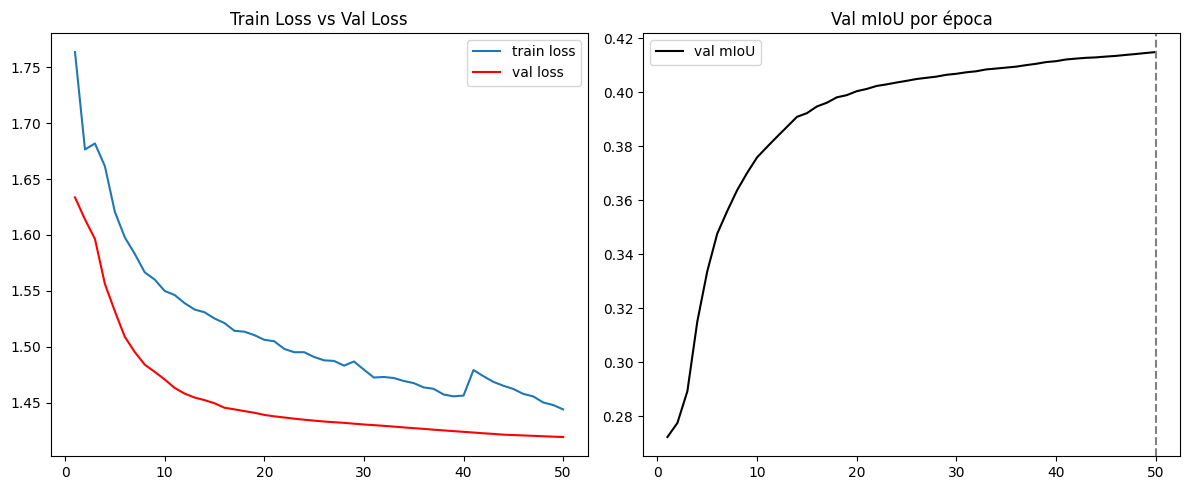

In [ ]:
import os
import shutil
import yaml
import torch
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
try:
    from ultralytics import YOLO
except ImportError:
    print("Instalando Ultralytics...")
    !pip install ultralytics
    from ultralytics import YOLO

base_dir = '/content'
os.chdir(base_dir)

ruta_dataset_dia = './content/dataset_day_retinex'
ruta_dataset_noche = './content/dataset_night_clahe'
archivo_json_etiquetas = './json_data/bdd100k_labels_images_train.json'
yolov8_dataset_base_path = './yolov8_dataset'

images_all = os.path.join(yolov8_dataset_base_path, 'images/all')
labels_all = os.path.join(yolov8_dataset_base_path, 'labels/all')

#PREPARACIÓN Y UNIFICACIÓN DE CARPETAS
if os.path.exists(yolov8_dataset_base_path):
    shutil.rmtree(yolov8_dataset_base_path)

os.makedirs(images_all, exist_ok=True)
os.makedirs(labels_all, exist_ok=True)

print("\n--- Cargando etiquetas JSON ---")
with open(archivo_json_etiquetas, 'r', encoding='utf-8') as f:
    bdd_labels = json.load(f)
bdd_map = {e['name']: e for e in bdd_labels}

img_list = []
for d in [ruta_dataset_dia, ruta_dataset_noche]:
    if os.path.exists(d):
        img_list.extend(glob.glob(os.path.join(d, '**', '*.jpg'), recursive=True))
        img_list.extend(glob.glob(os.path.join(d, '**', '*.png'), recursive=True))

class_mapping = {'car': 0, 'truck': 1, 'bus': 2, 'motorcycle': 3, 'bicycle': 4, 'person': 5, 'train': 6, 'traffic light': 7, 'traffic sign': 8}
IMG_W, IMG_H = 1280, 720

def convert_to_yolo(box):
    xc = ((box['x1'] + box['x2']) / 2) / IMG_W
    yc = ((box['y1'] + box['y2']) / 2) / IMG_H
    w = (box['x2'] - box['x1']) / IMG_W
    h = (box['y2'] - box['y1']) / IMG_H
    return f"{xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"

print("--- Convirtiendo a formato YOLO ---")
count = 0
for img_path in tqdm(img_list):
    name = os.path.basename(img_path)
    entry = bdd_map.get(name) or bdd_map.get(os.path.splitext(name)[0])

    if entry:
        yolo_data = []
        for lbl in entry.get('labels', []):
            if lbl['category'] in class_mapping and 'box2d' in lbl:
                yolo_data.append(f"{class_mapping[lbl['category']]} {convert_to_yolo(lbl['box2d'])}")

        if yolo_data:
            shutil.copy(img_path, os.path.join(images_all, name))
            with open(os.path.join(labels_all, os.path.splitext(name)[0]+'.txt'), 'w') as f:
                f.write("\n".join(yolo_data))
            count += 1

imgs = [os.path.splitext(f)[0] for f in os.listdir(images_all)]
tr, temp = train_test_split(imgs, test_size=0.3, random_state=42)
val, ts = train_test_split(temp, test_size=0.5, random_state=42)

def move_data(names, folder):
    os.makedirs(os.path.join(yolov8_dataset_base_path, 'images', folder), exist_ok=True)
    os.makedirs(os.path.join(yolov8_dataset_base_path, 'labels', folder), exist_ok=True)
    for n in names:
        for ext in ['.jpg', '.png']:
            orig = os.path.join(images_all, n + ext)
            if os.path.exists(orig):
                shutil.move(orig, os.path.join(yolov8_dataset_base_path, 'images', folder, n + ext))
        shutil.move(os.path.join(labels_all, n + '.txt'), os.path.join(yolov8_dataset_base_path, 'labels', folder, n + '.txt'))

move_data(tr, 'train'); move_data(val, 'val'); move_data(ts, 'test')
shutil.rmtree(images_all); shutil.rmtree(labels_all)

yaml_path = os.path.join(yolov8_dataset_base_path, 'bdd100k.yaml')
data_yaml = {
    'path': os.path.abspath(yolov8_dataset_base_path),
    'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
    'names': {i: n for n, i in class_mapping.items()}
}
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = YOLO('yolov8n.pt')

results_train = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    device=device,
    project='YOLO_Project',
    name='run_bdd',
    resume=True
)

try:
    res_path = os.path.join(model.trainer.save_dir, 'results.csv')
    df = pd.read_csv(res_path)
    df.columns = [c.strip() for c in df.columns]
    best_epoch_idx = df['metrics/mAP50(B)'].idxmax()

    plt.figure(figsize=(12, 5))

    # Gráfica Loss
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train/box_loss'], label='train loss')
    plt.plot(df['epoch'], df['val/box_loss'], label='val loss', color='red')
    plt.title('Train Loss vs Val Loss')
    plt.legend()

    # Gráfica mIoU
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], color='black', label='val mIoU')
    plt.axvline(x=df.loc[best_epoch_idx, 'epoch'], color='gray', linestyle='--')
    plt.title('Val mIoU por época')
    plt.legend()

    plt.tight_layout()
    plt.savefig('resultado_entrenamiento.png')
    plt.show()
except Exception as e:
    print(f"No se pudieron generar las gráficas: {e}")

Gráficas

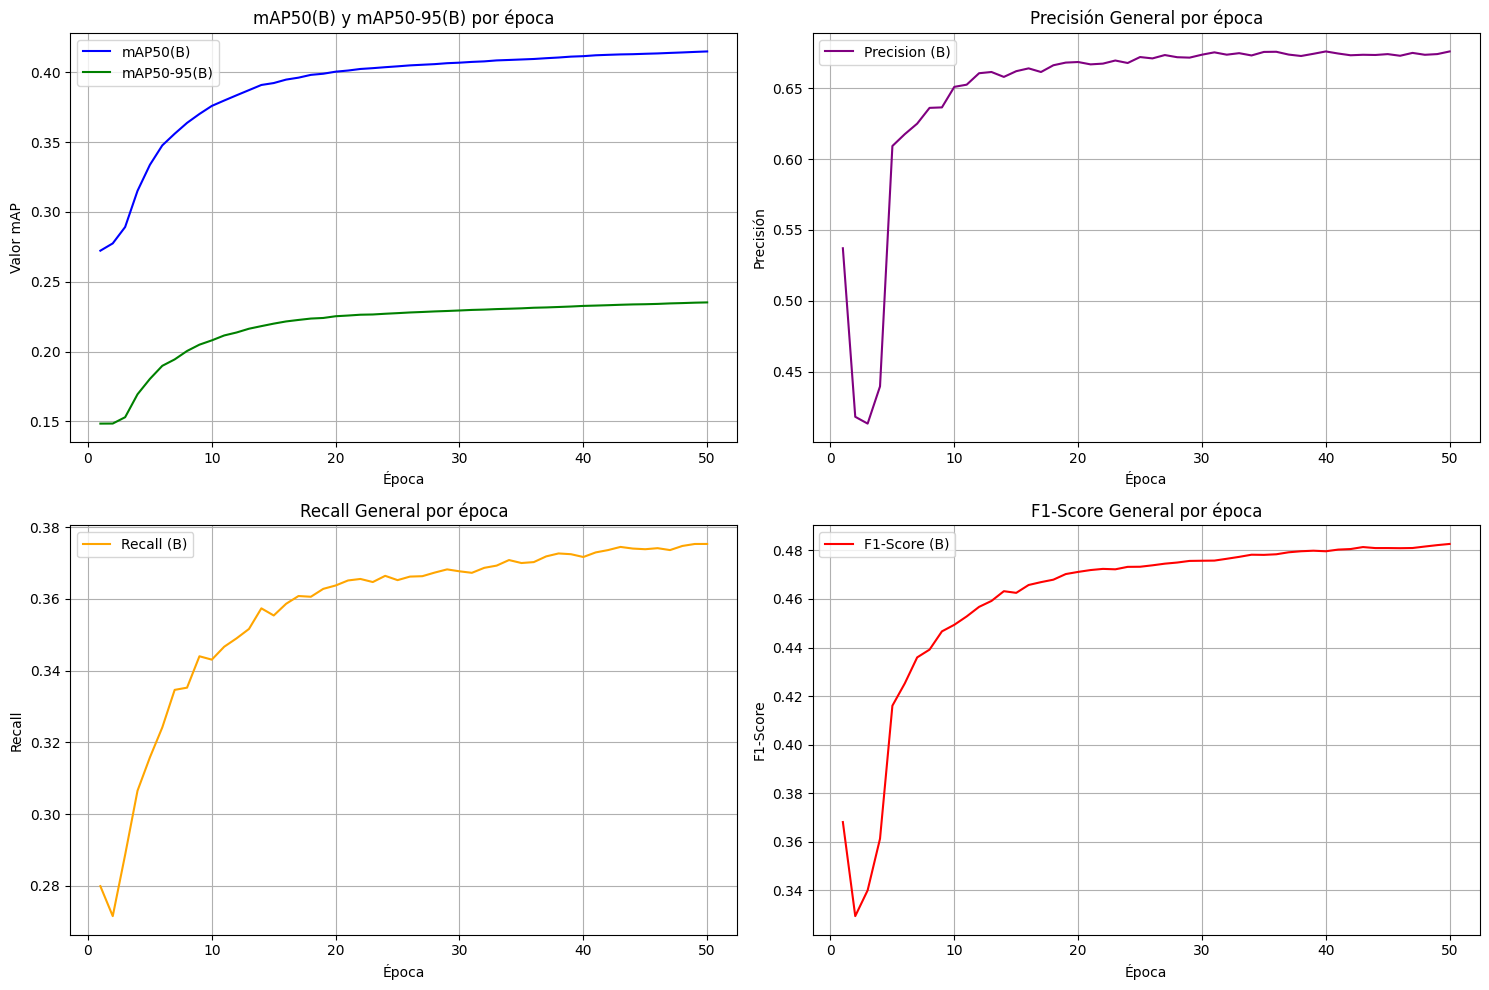

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# gráfica de mAP50 y mAP50-95
plt.subplot(2, 2, 1)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50(B)', color='blue')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95(B)', color='green')
plt.title('mAP50(B) y mAP50-95(B) por época')
plt.xlabel('Época')
plt.ylabel('Valor mAP')
plt.legend()
plt.grid(True)

# Gráfica de presición
plt.subplot(2, 2, 2)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision (B)', color='purple')
plt.title('Precisión General por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Recall
plt.subplot(2, 2, 3)
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall (B)', color='orange')
plt.title('Recall General por época')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

# Gráfica de F1 score
f1_score = (2 * df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'] + epsilon)

plt.subplot(2, 2, 4)
plt.plot(df['epoch'], f1_score, label='F1-Score (B)', color='red')
plt.title('F1-Score General por época')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
model.save('modelo_YOLOv8_deteccion_v2')